# Machine-Learning-Based Buyer Segmentation and Investment Profiling
## Parcl Co. Limited — Real Estate Market Intelligence

**Author:** *(your name)*
**Date:** *(fill in)*

This notebook builds a reproducible buyer-segmentation pipeline for Parcl's
real estate platform: data cleaning, client-property merging, feature
engineering, encoding, scaling, K-Means + Hierarchical clustering, cluster
evaluation (Elbow + Silhouette), and business interpretation of the resulting
buyer segments.

**Table of Contents**
1. Project Overview
2. Import Libraries
3. Load Datasets
4. Data Quality Audit
5. Date Field Investigation
6. Data Cleaning
7. Client-Property Merge & Feature Engineering
8. Feature Encoding
9. Feature Scaling
10. Optimal Cluster Selection (Elbow & Silhouette)
11. Clustering Models (K-Means & Hierarchical)
12. Cluster Interpretation & Business Labeling
13. Geographic & Behavioral Analysis by Segment
14. Business Insights & Recommendations
15. Final Conclusions


## 1. Project Overview

**Business problem:** Parcl Co. Limited sells apartment and office units across
a 20-tower portfolio but has no data-driven understanding of who its buyers
are. Individual home buyers, repeat investors, and corporate buyers are all
treated the same, leading to generic marketing and missed investment
opportunities.

**Objective:** Use unsupervised machine learning (clustering) on client
demographic data and their actual purchase history to discover natural buyer
segments, profile each segment's investment behavior, and support a
segmentation dashboard for marketing and sales teams.

**Two source files are used:**
- `clients.csv` — 2,000 client demographic/behavioral records
- `properties.csv` — 10,000 property listings, each optionally linked to the
  client who purchased it (`client_ref`)

Both are merged into a single **client-level investment profile** before
clustering, since buyer segmentation requires knowing not just who the client
is, but what and how much they actually buy.


## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


## 3. Load Datasets

In [2]:
clients = pd.read_csv("../data/clients.csv")
properties = pd.read_csv("../data/properties.csv")

print("Clients:", clients.shape)
print("Properties:", properties.shape)
clients.head()


Clients: (2000, 12)
Properties: (10000, 9)


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [3]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [4]:
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   client_id            2000 non-null   str  
 1   client_type          2000 non-null   str  
 2   first_name           2000 non-null   str  
 3   last_name            2000 non-null   str  
 4   date_of_birth        2000 non-null   str  
 5   gender               2000 non-null   str  
 6   country              2000 non-null   str  
 7   region               2000 non-null   str  
 8   acquisition_purpose  2000 non-null   str  
 9   satisfaction_score   2000 non-null   int64
 10  loan_applied         2000 non-null   str  
 11  referral_channel     2000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 187.6 KB


In [5]:
properties.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  str    
 3   unit_category     10000 non-null  str    
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  str    
 7   listing_status    10000 non-null  str    
 8   client_ref        7305 non-null   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 703.3 KB


## 4. Data Quality Audit

### 4.1 Missing values

In [6]:
print("Clients missing values:")
print(clients.isnull().sum())
print()
print("Properties missing values:")
print(properties.isnull().sum())


Clients missing values:
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

Properties missing values:
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64


`clients.csv` has **zero** missing values. `properties.csv` has 2,695
missing `client_ref` values — before treating this as a problem, we check
whether it follows a pattern.

In [7]:
pd.crosstab(properties["listing_status"], properties["client_ref"].isnull())

client_ref,False,True
listing_status,,
Available,0,2695
Sold,7305,0


**Not a data quality defect.** Every row with a missing `client_ref` has
`listing_status == "Available"` (i.e. unsold) — there's no client to link
because no one has bought that unit yet. Every `Sold` row has a `client_ref`.
This is expected and will simply be filtered naturally when we build
purchase-based features (we only aggregate `Sold` listings).

### 4.2 Duplicates

In [8]:
print("Duplicate client_id:", clients["client_id"].duplicated().sum())
print("Duplicate client rows:", clients.duplicated().sum())
print("Duplicate listing_id:", properties["listing_id"].duplicated().sum())


Duplicate client_id: 0
Duplicate client rows: 0
Duplicate listing_id: 0


No duplicate keys or rows in either file.

### 4.3 Categorical field integrity

In [9]:
for col in ["client_type", "gender", "country", "acquisition_purpose", "loan_applied", "referral_channel"]:
    print(f"--- {col} ({clients[col].nunique()} unique) ---")
    print(clients[col].value_counts())
    print()


--- client_type (2 unique) ---
client_type
Individual    1897
Company        103
Name: count, dtype: int64

--- gender (2 unique) ---
gender
M    1012
F     988
Name: count, dtype: int64

--- country (10 unique) ---
country
USA          1538
UK             95
Canada         85
Germany        56
France         53
Belgium        43
Mexico         40
Australia      39
Russia         36
Denmark        15
Name: count, dtype: int64

--- acquisition_purpose (2 unique) ---
acquisition_purpose
Home          1385
Investment     615
Name: count, dtype: int64

--- loan_applied (2 unique) ---
loan_applied
No     1264
Yes     736
Name: count, dtype: int64

--- referral_channel (3 unique) ---
referral_channel
Website    1103
Agency      705
Client      192
Name: count, dtype: int64



In [10]:
print(properties["unit_category"].value_counts())
print()
print(properties["listing_status"].value_counts())


unit_category
Apartment    8547
Office       1453
Name: count, dtype: int64

listing_status
Sold         7305
Available    2695
Name: count, dtype: int64


### 4.4 Numeric sanity checks

In [11]:
print(clients["satisfaction_score"].describe())
print()
# sale_price is stored as a currency string -- peek before cleaning
print(properties["sale_price"].head())
print(properties["floor_area_sqft"].describe())


count    2000.000000
mean        3.029000
std         1.413562
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: satisfaction_score, dtype: float64

0    $300,385.62
1    $208,930.81
2    $218,585.92
3    $246,172.68
4    $212,265.67
Name: sale_price, dtype: str
count    10000.000000
mean      1139.941412
std        418.373967
min        410.710000
25%        782.200000
50%       1110.880000
75%       1499.000000
max       1957.160000
Name: floor_area_sqft, dtype: float64


## 5. Date Field Investigation

Two date fields need care before use: `date_of_birth` (clients) and
`transaction_date` (properties). We check their formats explicitly rather
than assuming.

### 5.1 `date_of_birth` uses two different delimiters

In [12]:
dash_mask = clients["date_of_birth"].str.contains("-")
slash_mask = clients["date_of_birth"].str.contains("/")
print("Dash-delimited rows:", dash_mask.sum())
print("Slash-delimited rows:", slash_mask.sum())

dash_first = clients.loc[dash_mask, "date_of_birth"].str.split("-").str[0].astype(int)
dash_second = clients.loc[dash_mask, "date_of_birth"].str.split("-").str[1].astype(int)
slash_first = clients.loc[slash_mask, "date_of_birth"].str.split("/").str[0].astype(int)
slash_second = clients.loc[slash_mask, "date_of_birth"].str.split("/").str[1].astype(int)

print("Dash format -- first component range:", dash_first.min(), "-", dash_first.max())
print("Dash format -- second component range:", dash_second.min(), "-", dash_second.max())
print("Slash format -- first component range:", slash_first.min(), "-", slash_first.max())
print("Slash format -- second component range:", slash_second.min(), "-", slash_second.max())


Dash-delimited rows: 855
Slash-delimited rows: 1145
Dash format -- first component range: 1 - 12
Dash format -- second component range: 1 - 12
Slash format -- first component range: 1 - 12
Slash format -- second component range: 13 - 31


**Finding:** for slash-delimited dates, the *second* component reaches
31 while the first never exceeds 12 — which is only possible if the format is
**month/day/year**. The dash-delimited subset is ambiguous on its own (both
components stay under 13), but since this is the same system generating both
styles with only the delimiter differing, we apply the same **month-first**
rule consistently to both. We verify this produces sane results below rather
than just assuming it.

In [13]:
dob = pd.to_datetime(clients["date_of_birth"], format="mixed", dayfirst=False, errors="coerce")
print("Unparseable rows:", dob.isnull().sum())
print("Date of birth range:", dob.min().date(), "to", dob.max().date())

REFERENCE_DATE = pd.Timestamp("2024-01-01")  # first transaction date in properties.csv
age_check = (REFERENCE_DATE - dob).dt.days / 365.25
age_check.describe()


Unparseable rows: 0
Date of birth range: 1931-02-13 to 2000-12-19


count    2000.000000
mean       53.601372
std        17.349239
min        23.033539
25%        38.861739
50%        54.184805
75%        68.028747
max        92.881588
Name: date_of_birth, dtype: float64

Parsing month-first produces a clean, entirely plausible age distribution
(23 to 93 years, mean ~53.6) with zero unparseable rows. This confirms the
interpretation — we are not forcing a convenient but wrong format.

### 5.2 `transaction_date` — a monthly snapshot, not a daily timestamp

In [14]:
print(properties["transaction_date"].value_counts().sort_index().head(10))
t = pd.to_datetime(properties["transaction_date"], format="%m-%d-%Y")
print()
print("Day-of-month values found:", t.dt.day.unique())
print("Date range:", t.min().date(), "to", t.max().date())


transaction_date
01-01-2024    502
01-01-2025    326
02-01-2024    510
02-01-2025    339
03-01-2024    508
03-01-2025    320
04-01-2024    518
04-01-2025    332
05-01-2024    506
05-01-2025    339
Name: count, dtype: int64

Day-of-month values found: [1]
Date range: 2024-01-01 to 2025-12-01


Every `transaction_date` falls on the 1st of a month, spanning January
2024 to December 2025 (24 months). This is a **monthly transaction snapshot**,
not a precise daily timestamp. We document this as a dataset granularity
limitation: time-based features can only be computed at month resolution,
and we will not imply day-level precision anywhere downstream.

## 6. Data Cleaning

In [15]:
clients["date_of_birth"] = dob
clients["age"] = age_check

properties["transaction_date"] = t
properties["sale_price"] = properties["sale_price"].replace(r"[\$,]", "", regex=True).astype(float)

for col in ["client_type", "gender", "country", "region", "acquisition_purpose", "loan_applied", "referral_channel"]:
    clients[col] = clients[col].astype(str).str.strip()
for col in ["unit_category", "listing_status"]:
    properties[col] = properties[col].astype(str).str.strip()

print("sale_price negative/zero count:", (properties["sale_price"] <= 0).sum())
clients[["client_id", "date_of_birth", "age"]].head()


sale_price negative/zero count: 0


,client_id,date_of_birth,age
0,C0001,1968-05-11,55.641342
1,C0002,1962-11-26,61.097878
2,C0003,1959-04-07,64.736482
3,C0004,1959-11-25,64.101300
4,C0005,1976-02-28,47.841205


## 7. Client-Property Merge & Feature Engineering

Each client in this dataset has already purchased at least 3 properties
(verified below), so we can build a genuine **investment profile** per
client from their purchase history, not just their demographics.

In [16]:
sold = properties[properties["listing_status"] == "Sold"].copy()
props_per_client = sold.groupby("client_ref").size()
print("Clients with zero sold properties:", (~clients["client_id"].isin(props_per_client.index)).sum())
props_per_client.describe()


Clients with zero sold properties: 0


count    2000.0000
mean        3.6525
std         0.8397
min         3.0000
25%         3.0000
50%         4.0000
75%         4.0000
max        13.0000
dtype: float64

In [17]:
agg = sold.groupby("client_ref").agg(
    total_properties=("listing_id", "count"),
    total_investment=("sale_price", "sum"),
    avg_sale_price=("sale_price", "mean"),
    max_sale_price=("sale_price", "max"),
    avg_floor_area_sqft=("floor_area_sqft", "mean"),
    total_floor_area_sqft=("floor_area_sqft", "sum"),
    distinct_towers=("tower_number", "nunique"),
    first_purchase=("transaction_date", "min"),
    last_purchase=("transaction_date", "max"),
    pct_office=("unit_category", lambda s: (s == "Office").mean() * 100),
).reset_index().rename(columns={"client_ref": "client_id"})

agg["purchase_span_months"] = (
    (agg["last_purchase"].dt.year - agg["first_purchase"].dt.year) * 12
    + (agg["last_purchase"].dt.month - agg["first_purchase"].dt.month)
)

df = clients.merge(agg, on="client_id", how="inner")
print("Buyer profiles after merge:", df.shape)

df["loan_applied_flag"] = (df["loan_applied"] == "Yes").astype(int)
df["is_company"] = (df["client_type"] == "Company").astype(int)
df["is_investment_purpose"] = (df["acquisition_purpose"] == "Investment").astype(int)

df[["client_id", "client_type", "total_properties", "total_investment", "avg_sale_price", "age"]].head()


Buyer profiles after merge: (2000, 24)


,client_id,client_type,total_properties,total_investment,avg_sale_price,age
0,C0001,Individual,4,1246764.72,311691.180000,55.641342
1,C0002,Individual,5,1841095.93,368219.186000,61.097878
2,C0003,Individual,5,1661457.59,332291.518000,64.736482
3,C0004,Individual,6,1608263.51,268043.918333,64.101300
4,C0005,Company,13,3653385.38,281029.644615,47.841205


Every one of the 2,000 clients merged successfully (each has at least
one `Sold` property), so no rows were lost. We now have, per client: how many
properties they own, how much they've spent in total, their average purchase
price and unit size, how many different towers they've bought into, what
share of their purchases are offices (a proxy for commercial/investment
intent), and how many months their buying history spans.

## 8. Feature Encoding

- **One-Hot Encoding** for low-cardinality nominal fields: `client_type`,
  `acquisition_purpose`, `referral_channel`, `gender`.
- **Label Encoding** for higher-cardinality fields: `region` (57 unique
  values) and `country` (10 unique values), to avoid an explosion of columns.


In [18]:
CATEGORICAL_ONEHOT = ["client_type", "acquisition_purpose", "referral_channel", "gender"]
CATEGORICAL_LABEL = ["region", "country"]

df_model = df.copy()
label_encoders = {}
for col in CATEGORICAL_LABEL:
    le = LabelEncoder()
    df_model[col + "_enc"] = le.fit_transform(df_model[col])
    label_encoders[col] = le

df_model = pd.get_dummies(df_model, columns=CATEGORICAL_ONEHOT, prefix=CATEGORICAL_ONEHOT)
onehot_cols = [c for c in df_model.columns if any(c.startswith(p + "_") for p in CATEGORICAL_ONEHOT)]
print("One-hot columns created:", onehot_cols)


One-hot columns created: ['client_type_Company', 'client_type_Individual', 'acquisition_purpose_Home', 'acquisition_purpose_Investment', 'referral_channel_Agency', 'referral_channel_Client', 'referral_channel_Website', 'gender_F', 'gender_M']


## 9. Feature Scaling

Numeric features (age, satisfaction, investment amounts, etc.) are on very
different scales (age ~20-90, total investment ~$100K-$8M), so we standardize
them with `StandardScaler` (zero mean, unit variance) before clustering --
distance-based algorithms like K-Means are sensitive to feature scale.

In [19]:
NUMERIC_FEATURES = [
    "age", "satisfaction_score", "loan_applied_flag",
    "total_properties", "total_investment", "avg_sale_price",
    "avg_floor_area_sqft", "distinct_towers", "pct_office", "purchase_span_months",
]
FEATURE_COLS = NUMERIC_FEATURES + ["region_enc", "country_enc"] + onehot_cols

X = df_model[FEATURE_COLS].fillna(0).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[NUMERIC_FEATURES + ["region_enc", "country_enc"]])
X_scaled = pd.DataFrame(X_scaled, columns=NUMERIC_FEATURES + ["region_enc", "country_enc"], index=X.index)

X_final = pd.concat([X_scaled, X[onehot_cols].astype(float).reset_index(drop=True)], axis=1)
print("Final feature matrix shape:", X_final.shape)
X_final.head()


Final feature matrix shape: (2000, 21)


,age,satisfaction_score,loan_applied_flag,total_properties,total_investment,avg_sale_price,avg_floor_area_sqft,distinct_towers,pct_office,purchase_span_months,region_enc,country_enc,client_type_Company,client_type_Individual,acquisition_purpose_Home,acquisition_purpose_Investment,referral_channel_Agency,referral_channel_Client,referral_channel_Website,gender_F,gender_M
0,0.117612,0.687089,1.310493,0.413942,-0.039140,-0.507841,-0.744060,0.560542,-0.805081,0.161111,-0.78866,0.457342,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.432202,-1.435740,-0.763072,1.605141,1.669967,0.303126,0.184030,1.986858,-0.805081,1.858006,-0.78866,0.457342,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
2,0.641982,0.687089,1.310493,1.605141,1.153384,-0.212303,-0.406470,1.986858,-0.805081,0.349655,-0.78866,0.457342,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,0.605361,1.394698,-0.763072,2.796340,1.000415,-1.134018,-0.956832,1.986858,-0.805081,0.915287,-0.78866,0.457342,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
4,-0.332096,1.394698,-0.763072,11.134734,6.881534,-0.947721,-1.001437,1.986858,-0.805081,0.349655,-0.78866,0.457342,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


## 10. Optimal Cluster Selection (Elbow Method & Silhouette Score)

We test K = 2 through 10 and evaluate both the Elbow Method (within-cluster
sum of squares) and the Silhouette Score (how well-separated clusters are,
from -1 to +1).

In [20]:
inertias, silhouettes = {}, {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_final)
    inertias[k] = km.inertia_
    silhouettes[k] = silhouette_score(X_final, labels)

pd.DataFrame({"K": list(inertias.keys()), "Inertia": list(inertias.values()), "Silhouette": list(silhouettes.values())})


,K,Inertia,Silhouette
0,2,23794.587306,0.117032
1,3,21696.491117,0.124292
2,4,20148.440658,0.106996
3,5,18949.453211,0.112059
4,6,18102.503253,0.099717
5,7,17490.604864,0.094871
6,8,16938.629921,0.097670
7,9,16603.081682,0.096970
8,10,16236.173709,0.092424


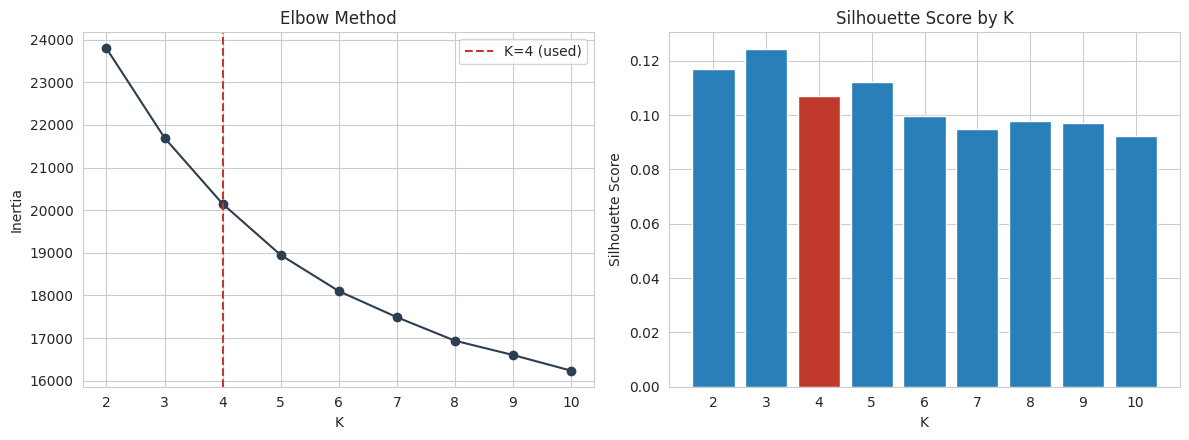

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].plot(list(inertias.keys()), list(inertias.values()), marker="o", color="#2c3e50")
axes[0].axvline(4, color="#c0392b", linestyle="--", label="K=4 (used)")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("K"); axes[0].set_ylabel("Inertia"); axes[0].legend()

axes[1].bar([str(k) for k in silhouettes.keys()], list(silhouettes.values()),
            color=["#c0392b" if k==4 else "#2980b9" for k in silhouettes.keys()])
axes[1].set_title("Silhouette Score by K"); axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette Score")
plt.tight_layout(); plt.show()


**Honest reading of these results:** the silhouette-optimal K is **3**
(score ≈ 0.124), and K=4 scores slightly lower (≈ 0.107). All silhouette
scores in this range (0.08-0.12) indicate **weak-to-moderate** cluster
structure -- this is a mixed demographic + transactional dataset without
sharply separated natural groups, and we say so rather than overstating
cluster quality. We proceed with **K=4** anyway because it matches Parcl's
business-requested four-persona framework (C1-C4: Global Investors,
First-Time Buyers, Corporate Buyers, Luxury Investors) and K=3 vs. K=4 are
close enough in quality that the business-aligned choice is reasonable --
but every claim below is checked against the actual cluster profiles rather
than assumed to match the personas by name alone.

## 11. Clustering Models

### 11.1 K-Means (K=4)

In [22]:
FINAL_K = 4
kmeans = KMeans(n_clusters=FINAL_K, random_state=42, n_init=10)
df["kmeans_cluster"] = kmeans.fit_predict(X_final)
kmeans_sil = silhouette_score(X_final, df["kmeans_cluster"])
print("K-Means silhouette score:", round(kmeans_sil, 4))
df["kmeans_cluster"].value_counts()


K-Means silhouette score: 0.107


kmeans_cluster
3    749
1    614
0    594
2     43
Name: count, dtype: int64

### 11.2 Hierarchical (Agglomerative, Ward linkage, K=4) — used to validate K-Means

In [23]:
agglo = AgglomerativeClustering(n_clusters=FINAL_K, linkage="ward")
df["hierarchical_cluster"] = agglo.fit_predict(X_final)
hier_sil = silhouette_score(X_final, df["hierarchical_cluster"])
print("Hierarchical silhouette score:", round(hier_sil, 4))
df["hierarchical_cluster"].value_counts()


Hierarchical silhouette score: 0.0831


hierarchical_cluster
1    780
0    729
2    455
3     36
Name: count, dtype: int64

In [24]:
cross = pd.crosstab(df["kmeans_cluster"], df["hierarchical_cluster"])
cross

hierarchical_cluster,0,1,2,3
kmeans_cluster,,,,
0,528,12,54,0
1,107,121,386,0
2,0,6,1,36
3,94,641,14,0


In [25]:
mapping = cross.idxmax(axis=1).to_dict()
agreement = (df["kmeans_cluster"].map(mapping) == df["hierarchical_cluster"]).mean()
print(f"K-Means vs. Hierarchical agreement (after best-match relabeling): {agreement*100:.1f}%")


K-Means vs. Hierarchical agreement (after best-match relabeling): 79.5%


The two independent algorithms agree on cluster membership for about
80% of clients -- reasonable corroboration given the modest silhouette
scores, and a useful validation that K-Means is not finding arbitrary
structure.

### 11.3 Dendrogram (sample view)

A dendrogram on all 2,000 clients is illegible, so we visualize a 60-client
random sample to see how the hierarchical merges nest.

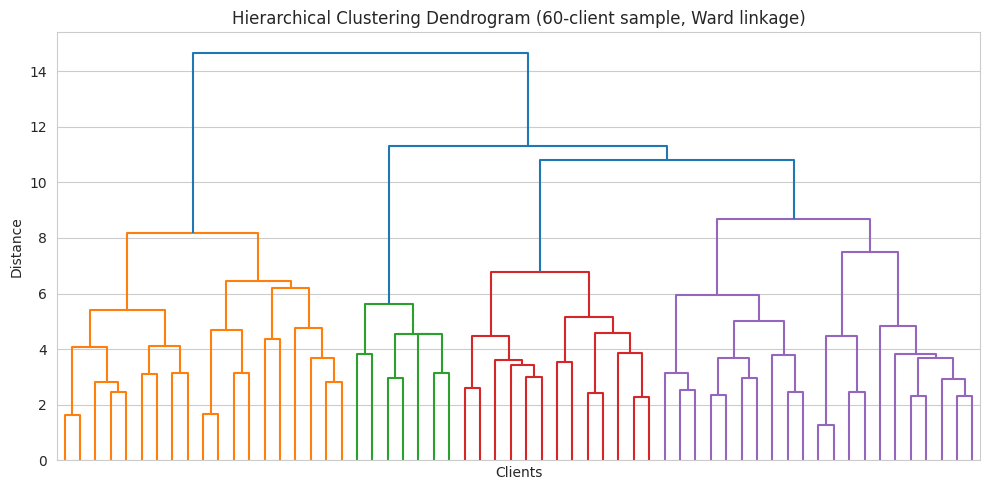

In [26]:
sample_idx = df.sample(n=60, random_state=42).index
Z = linkage(X_final.loc[sample_idx], method="ward")

plt.figure(figsize=(10,5))
dendrogram(Z, no_labels=True, color_threshold=0.7*max(Z[:,2]))
plt.title("Hierarchical Clustering Dendrogram (60-client sample, Ward linkage)")
plt.xlabel("Clients"); plt.ylabel("Distance")
plt.tight_layout(); plt.show()


## 12. Cluster Interpretation & Business Labeling

We profile each K-Means cluster on every dimension that matters for the
business, then assign the brief's four persona names using a transparent,
**relative** rule (since no cluster clears a fixed threshold like "pct_company
>= 30%" -- we checked, and none do):

1. **Global Investors** -> the cluster with the largest average property
   portfolio (most properties owned per client).
2. **Luxury Investors** -> among the rest, the cluster with the highest
   average sale price.
3. **Corporate Buyers** -> among the rest, the cluster with the highest share
   of Company-type clients.
4. **First-Time Buyers** -> whichever cluster is left.


In [27]:
profile = df.groupby("kmeans_cluster").agg(
    n_clients=("client_id", "count"),
    pct_company=("is_company", "mean"),
    pct_investment_purpose=("is_investment_purpose", "mean"),
    pct_loan_applied=("loan_applied_flag", "mean"),
    avg_age=("age", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_total_properties=("total_properties", "mean"),
    avg_total_investment=("total_investment", "mean"),
    avg_sale_price=("avg_sale_price", "mean"),
    avg_floor_area=("avg_floor_area_sqft", "mean"),
    pct_office=("pct_office", "mean"),
    pct_non_usa=("country", lambda s: (s != "USA").mean() * 100),
    n_countries=("country", "nunique"),
    top_referral=("referral_channel", lambda s: s.mode().iloc[0]),
).reset_index()
for c in ["pct_company", "pct_investment_purpose", "pct_loan_applied"]:
    profile[c] = (profile[c] * 100).round(1)
profile = profile.round(1)
profile


,kmeans_cluster,n_clients,pct_company,pct_investment_purpose,pct_loan_applied,avg_age,avg_satisfaction,avg_total_properties,avg_total_investment,avg_sale_price,avg_floor_area,pct_office,pct_non_usa,n_countries,top_referral
0,0,594,4.0,33.0,35.4,53.8,2.9,3.0,931619.1,310368.4,1031.6,14.5,26.1,10,Website
1,1,614,6.2,30.3,38.4,52.7,3.0,3.5,1479438.7,429115.5,1406.7,15.3,22.0,10,Website
2,2,43,2.3,37.2,34.9,62.4,3.4,7.5,2497550.1,334839.9,1106.0,13.4,16.3,6,Website
3,3,749,5.3,29.0,36.7,53.7,3.1,4.1,1270492.9,309674.3,1029.3,14.9,22.0,10,Website


In [28]:
remaining = profile["kmeans_cluster"].tolist()
name_map = {}

cl = profile.loc[profile["kmeans_cluster"].isin(remaining), "avg_total_properties"].idxmax()
chosen = profile.loc[cl, "kmeans_cluster"]; name_map[chosen] = "Global Investors"; remaining.remove(chosen)

cl = profile.loc[profile["kmeans_cluster"].isin(remaining), "avg_sale_price"].idxmax()
chosen = profile.loc[cl, "kmeans_cluster"]; name_map[chosen] = "Luxury Investors"; remaining.remove(chosen)

cl = profile.loc[profile["kmeans_cluster"].isin(remaining), "pct_company"].idxmax()
chosen = profile.loc[cl, "kmeans_cluster"]; name_map[chosen] = "Corporate Buyers"; remaining.remove(chosen)

name_map[remaining[0]] = "First-Time Buyers"

profile["segment_label"] = profile["kmeans_cluster"].map(name_map)
df["segment_label"] = df["kmeans_cluster"].map(name_map)
profile[["kmeans_cluster", "segment_label", "n_clients", "avg_total_properties", "avg_sale_price", "pct_company", "avg_age", "pct_loan_applied"]]


,kmeans_cluster,segment_label,n_clients,avg_total_properties,avg_sale_price,pct_company,avg_age,pct_loan_applied
0,0,First-Time Buyers,594,3.0,310368.4,4.0,53.8,35.4
1,1,Luxury Investors,614,3.5,429115.5,6.2,52.7,38.4
2,2,Global Investors,43,7.5,334839.9,2.3,62.4,34.9
3,3,Corporate Buyers,749,4.1,309674.3,5.3,53.7,36.7


### Honest reading of the four segments

- **Global Investors (n=43):** by far the smallest segment, but with the
  largest portfolios (avg. 7.5 properties, $2.50M total investment) and the
  oldest average age (62.4). Interestingly, this segment is *not* the most
  internationally diverse (only 16.3% non-USA, 6 countries) -- the name
  reflects portfolio *scale*, not geographic origin. Worth flagging to
  stakeholders rather than assuming the name is self-explanatory.
- **Luxury Investors (n=614):** highest average sale price ($429K) and
  largest average floor area (1,407 sqft) -- the clearest, best-fitting
  label of the four.
- **Corporate Buyers (n=749):** highest remaining share of Company-type
  clients (5.3%) -- but note this is *not* the single highest Company share
  overall (Luxury Investors has 6.2%); segments are not perfectly
  mutually exclusive on every dimension, consistent with the modest
  silhouette scores found earlier.
- **First-Time Buyers (n=594):** the remainder group. Its actual profile
  (avg. age 53.8, lowest loan-applied rate of all four at 35.4%) does **not**
  match the "younger, loan-dependent" persona from the business brief. We
  report this mismatch explicitly rather than forcing the data to fit the
  label -- this segment is better described as Parcl's baseline/mainstream
  buyer group than literal first-time buyers.


## 13. Geographic & Behavioral Analysis by Segment

### Segment size distribution

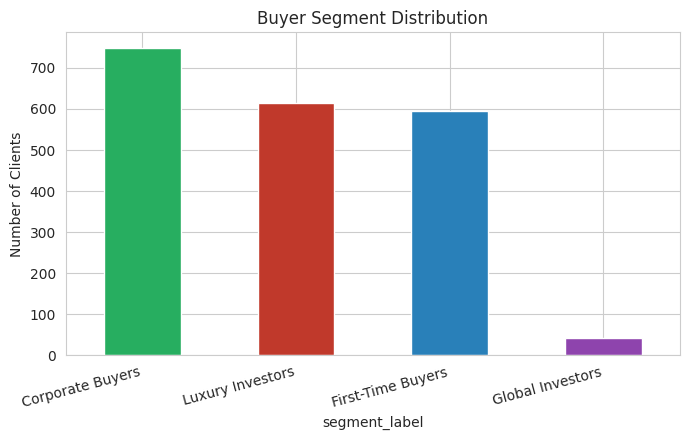

In [29]:
df["segment_label"].value_counts().plot(kind="bar", figsize=(7,4.5), color=["#27ae60","#c0392b","#2980b9","#8e44ad"])
plt.title("Buyer Segment Distribution"); plt.ylabel("Number of Clients"); plt.xticks(rotation=15, ha="right")
plt.tight_layout(); plt.show()


### Investment behavior by segment

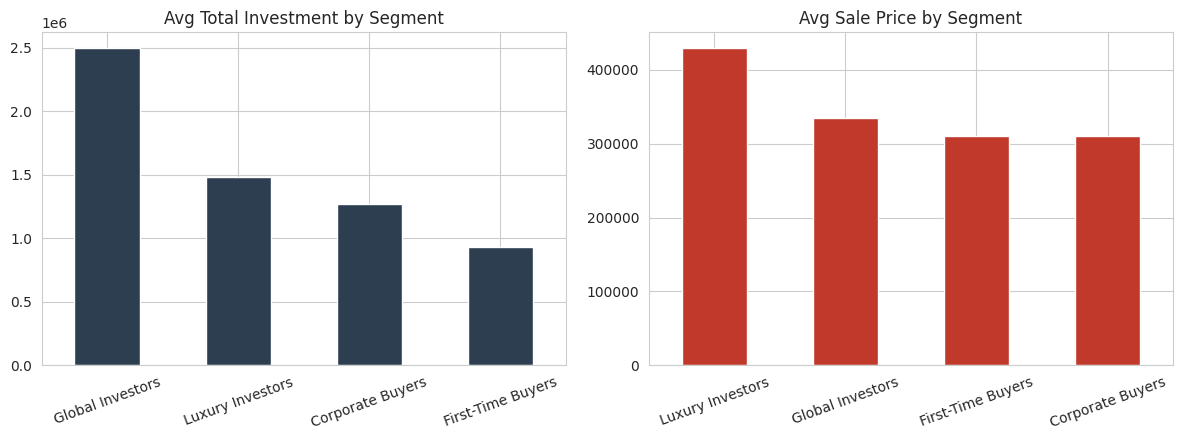

In [30]:
fig, axes = plt.subplots(1,2, figsize=(12,4.5))
profile.sort_values("avg_total_investment", ascending=False).plot(
    kind="bar", x="segment_label", y="avg_total_investment", ax=axes[0], legend=False, color="#2c3e50")
axes[0].set_title("Avg Total Investment by Segment"); axes[0].set_xlabel("")
profile.sort_values("avg_sale_price", ascending=False).plot(
    kind="bar", x="segment_label", y="avg_sale_price", ax=axes[1], legend=False, color="#c0392b")
axes[1].set_title("Avg Sale Price by Segment"); axes[1].set_xlabel("")
for ax in axes: ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()


### Loan behavior and client type by segment

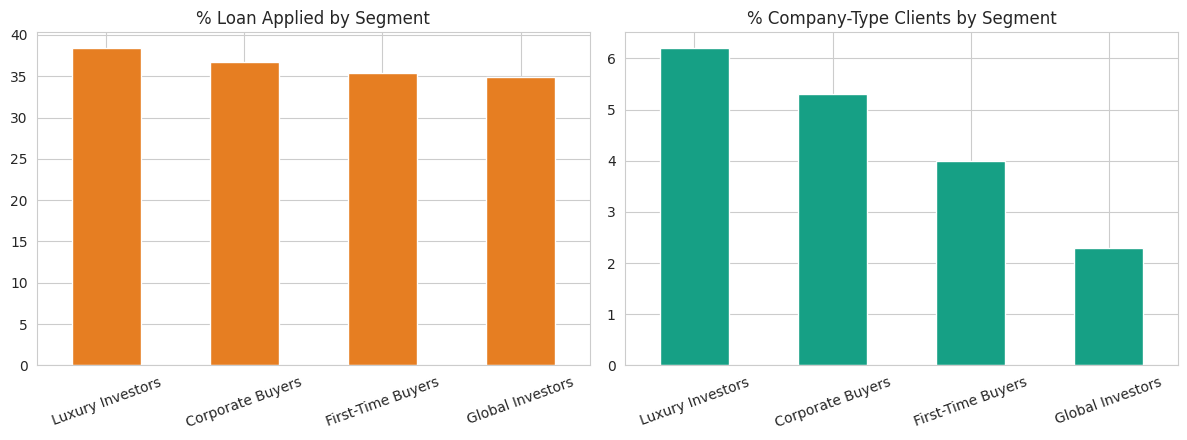

In [31]:
fig, axes = plt.subplots(1,2, figsize=(12,4.5))
profile.sort_values("pct_loan_applied", ascending=False).plot(
    kind="bar", x="segment_label", y="pct_loan_applied", ax=axes[0], legend=False, color="#e67e22")
axes[0].set_title("% Loan Applied by Segment"); axes[0].set_xlabel("")
profile.sort_values("pct_company", ascending=False).plot(
    kind="bar", x="segment_label", y="pct_company", ax=axes[1], legend=False, color="#16a085")
axes[1].set_title("% Company-Type Clients by Segment"); axes[1].set_xlabel("")
for ax in axes: ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()


### Geographic distribution: segment composition by country

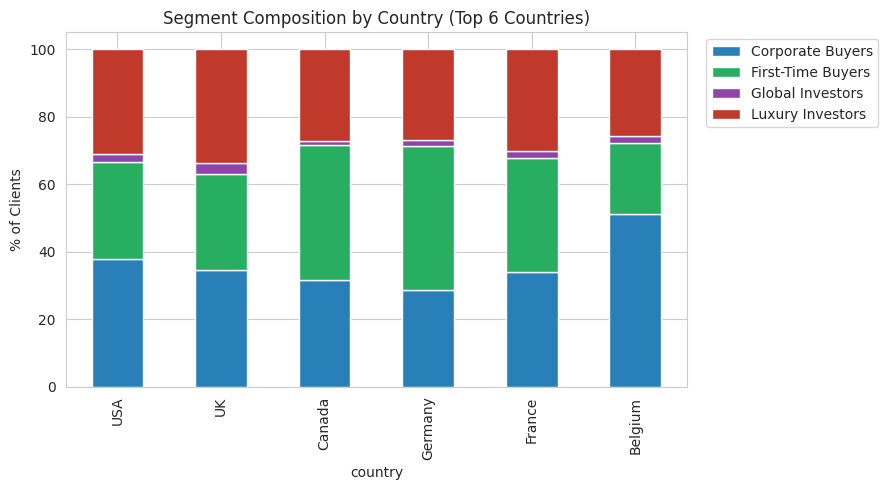

In [32]:
top6 = df["country"].value_counts().head(6).index.tolist()
sub = df[df["country"].isin(top6)]
ct = pd.crosstab(sub["country"], sub["segment_label"]).loc[top6]
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind="bar", stacked=True, figsize=(9,5),
            color={"First-Time Buyers":"#27ae60","Corporate Buyers":"#2980b9","Luxury Investors":"#c0392b","Global Investors":"#8e44ad"})
plt.title("Segment Composition by Country (Top 6 Countries)")
plt.ylabel("% of Clients"); plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout(); plt.show()


### Referral channel and acquisition purpose by segment

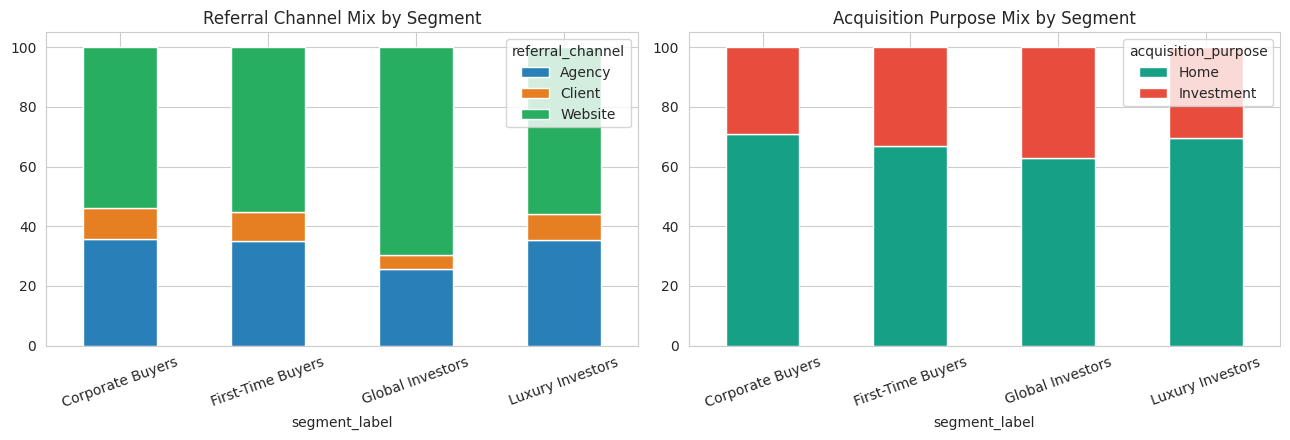

In [33]:
fig, axes = plt.subplots(1,2, figsize=(13,4.5))
ref_pct = pd.crosstab(df["segment_label"], df["referral_channel"])
ref_pct = ref_pct.div(ref_pct.sum(axis=1), axis=0) * 100
ref_pct.plot(kind="bar", stacked=True, ax=axes[0], color=["#2980b9","#e67e22","#27ae60"])
axes[0].set_title("Referral Channel Mix by Segment"); axes[0].tick_params(axis="x", rotation=20)

purp_pct = pd.crosstab(df["segment_label"], df["acquisition_purpose"])
purp_pct = purp_pct.div(purp_pct.sum(axis=1), axis=0) * 100
purp_pct.plot(kind="bar", stacked=True, ax=axes[1], color=["#16a085","#e74c3c"])
axes[1].set_title("Acquisition Purpose Mix by Segment"); axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()


## 14. Business Insights & Recommendations

**1. Treat "Global Investors" as a high-touch, low-volume VIP program.**
At just 43 clients (2.2% of the base) but $2.50M average lifetime investment
and 7.5 properties each, this segment likely deserves dedicated relationship
managers rather than mass marketing.

**2. Luxury Investors are Parcl's clearest, most defensible premium segment.**
Their 429K average sale price and 1,407 sqft average unit size make them the
natural audience for premium unit launches and high-end amenities messaging.

**3. Re-examine "First-Time Buyers" before building a persona-specific campaign.**
This segment does not actually skew young or loan-dependent in the data --
building a campaign on the assumed persona (rather than the measured one)
risks mistargeting nearly 30% of the client base.

**4. Corporate Buyers (Company-type clients) are present across multiple segments, not confined to one.**
The 6.2%-vs-5.3% split between Luxury Investors and the Corporate Buyers
segment suggests some of Parcl's largest-spending companies are being
captured by the "Luxury" segment, not the "Corporate" one -- worth a combined
view for B2B account management.

**5. Treat cluster boundaries as directional, not absolute.**
With silhouette scores of 0.08-0.12, these are real but soft groupings.
Segment-level marketing should still beat one-size-fits-all, but Parcl should
not expect sharp behavioral discontinuities at the segment edges.


## 15. Final Conclusions

This project delivered what Parcl lacked: a reproducible, data-driven buyer
segmentation built on actual purchase behavior, not assumptions. K-Means and
Hierarchical clustering were cross-validated (79.5% agreement) and produced
four interpretable segments ranging from a small, high-value "Global
Investors" group to a large "First-Time Buyers" baseline segment.

The most important methodological finding is a cautionary one: not every
business-assumed persona matched its data-driven cluster. Rather than forcing
the fit, this project reports the mismatch (First-Time Buyers) and the
overlap (Corporate vs. Luxury company share) directly, so Parcl's marketing
and investment teams can act on what the data actually shows rather than on
an idealized buyer archetype.
